# Markers

## Loading Packages

In [1]:
import warnings
warnings.filterwarnings('ignore')

import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append(r'../../../')
from SpatialCOC.preprocess import  preprocessing
from SpatialCOC.utils import replace_extreme_values, fix_seed, rotate_spatial_coordinates
fix_seed(2024)

## Loading Results

In [2]:
replicate = 3

## results of clusters
adata_analysis = sc.read_h5ad(f'../../Mouse_Thymus_Replicate{replicate}.h5ad')
print("the shape of adata_clusters:", np.shape(adata_analysis))

## oringinal expressions
adata_modality_1 = sc.read_h5ad(f'../../../Data/Mouse_Thymus_{replicate}/adata_RNA.h5ad')
adata_modality_2 = sc.read_h5ad(f'../../../Data/Mouse_Thymus_{replicate}/adata_ADT.h5ad')

adata_modality_1, adata_modality_2 = preprocessing(adata_modality_1, adata_modality_2, 'Stereo-CITE-seq')

the shape of adata_clusters: (4147, 0)
Stereo-CITE-seq data preprocessing have done!
Dimensions after preprocessed adata_modal_1: (4147, 3000)
Dimensions after preprocessing adata_modal_2: (4147, 19)


Marker orders:

replicate 1:    6, 4, 5, 7, 2, 3, 1

replicate 2:    1, 6, 3, 4, 2, 5, 7

replicate 3:    1, 3, 2, 5, 4, 6, 7


## Finding Marker Genes

In [3]:
adata_modality_1.obs['clusters'] = adata_analysis.obs['SpaKnit'].astype(str)
adata_modality_1.obs['clusters'] = adata_modality_1.obs['clusters'].astype('category')

In [4]:
# Now compute the dendrogram
sc.tl.dendrogram(adata_modality_1, groupby='clusters')

# Proceed with the rest of your analysis
sc.tl.rank_genes_groups(adata_modality_1, groupby='clusters', use_raw=False)

# Save marker genes
rank_genes = sc.get.rank_genes_groups_df(adata_modality_1, group=None)
rank_genes.to_excel(f'replicate{replicate}/marker_genes.xlsx', index=True)

         Falling back to preprocessing with `sc.pp.pca` and default params.


In [5]:
groups_orders = {
    1: ['6', '4', '5', '7', '2', '3', '1'],
    2: ['1', '6', '3', '4', '2', '5', '7'],
    3: ['1', '3', '2', '5', '4', '6', '7']
}   
groups_order = groups_orders[replicate]

n = 2
top_n_genes_per_group = rank_genes.groupby('group').head(n)
gene_dict = top_n_genes_per_group.groupby('group')['names'].apply(list).to_dict()
gene_dict = {group: gene_dict[group] for group in groups_order if group in gene_dict}
gene_dict

{'1': ['H2-K1', 'Rplp1'],
 '3': ['H2-K1', 'Rplp1'],
 '2': ['Cdk8', 'Camk1d'],
 '5': ['Rag1', 'Dntt'],
 '4': ['Rag1', 'Trbc2'],
 '6': ['Malat1', 'Themis'],
 '7': ['Gm26870', 'Tenm2']}

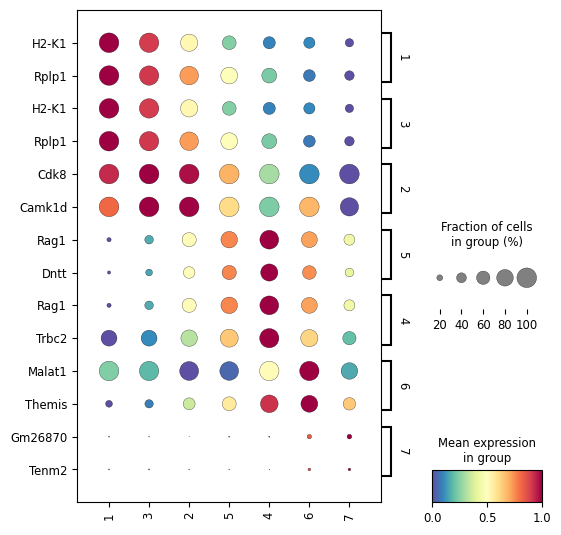

In [ ]:
fig = sc.pl.dotplot(
    adata_modality_1,
    var_names=gene_dict,
    groupby='clusters',
    categories_order=groups_order,
    use_raw=False,
    figsize=(6, 6),
    swap_axes=True,
    cmap='Spectral_r',    # 颜色方案
    standard_scale='var',  # 按基因标准化表达
    dot_max=1,
    dot_min=0,
    show=False,
    return_fig=True
)

plt.show()
fig.savefig(f'./replicate{replicate}/dotplot.png')

## Finding Marker Proteins

In [7]:
adata_modality_2.obs['clusters'] = adata_analysis.obs['SpaKnit'].astype(str)
adata_modality_2.obs['clusters'] = adata_modality_2.obs['clusters'].astype('category')

In [8]:
# Now compute the dendrogram
sc.tl.dendrogram(adata_modality_2, groupby='clusters')

# Proceed with the rest of your analysis
sc.tl.rank_genes_groups(adata_modality_2, groupby='clusters', use_raw=False)

# Save marker genes
rank_genes = sc.get.rank_genes_groups_df(adata_modality_2, group=None)
rank_genes.to_excel(f'replicate{replicate}/marker_proteins.xlsx', index=True)

In [9]:
n = 1
top_n_genes_per_group = rank_genes.groupby('group').head(n)
gene_dict = top_n_genes_per_group.groupby('group')['names'].apply(list).to_dict()
gene_dict = {group: gene_dict[group] for group in groups_order if group in gene_dict}

gene_list = [gene_dict[group] for group in groups_order]
gene_list = [item[0] for item in gene_list]
print(gene_list)

['mouse_human_CD44', 'mouse_CD11c', 'mouse_CD5', 'mouse_CD68', 'mouse_CD8a', 'mouse_F4_80', 'Mouse_IgG2a']


In [14]:
if replicate == 3:
    adata_modality_2.obsm['spatial'] = rotate_spatial_coordinates(adata_modality_2.obsm['spatial'], 90)

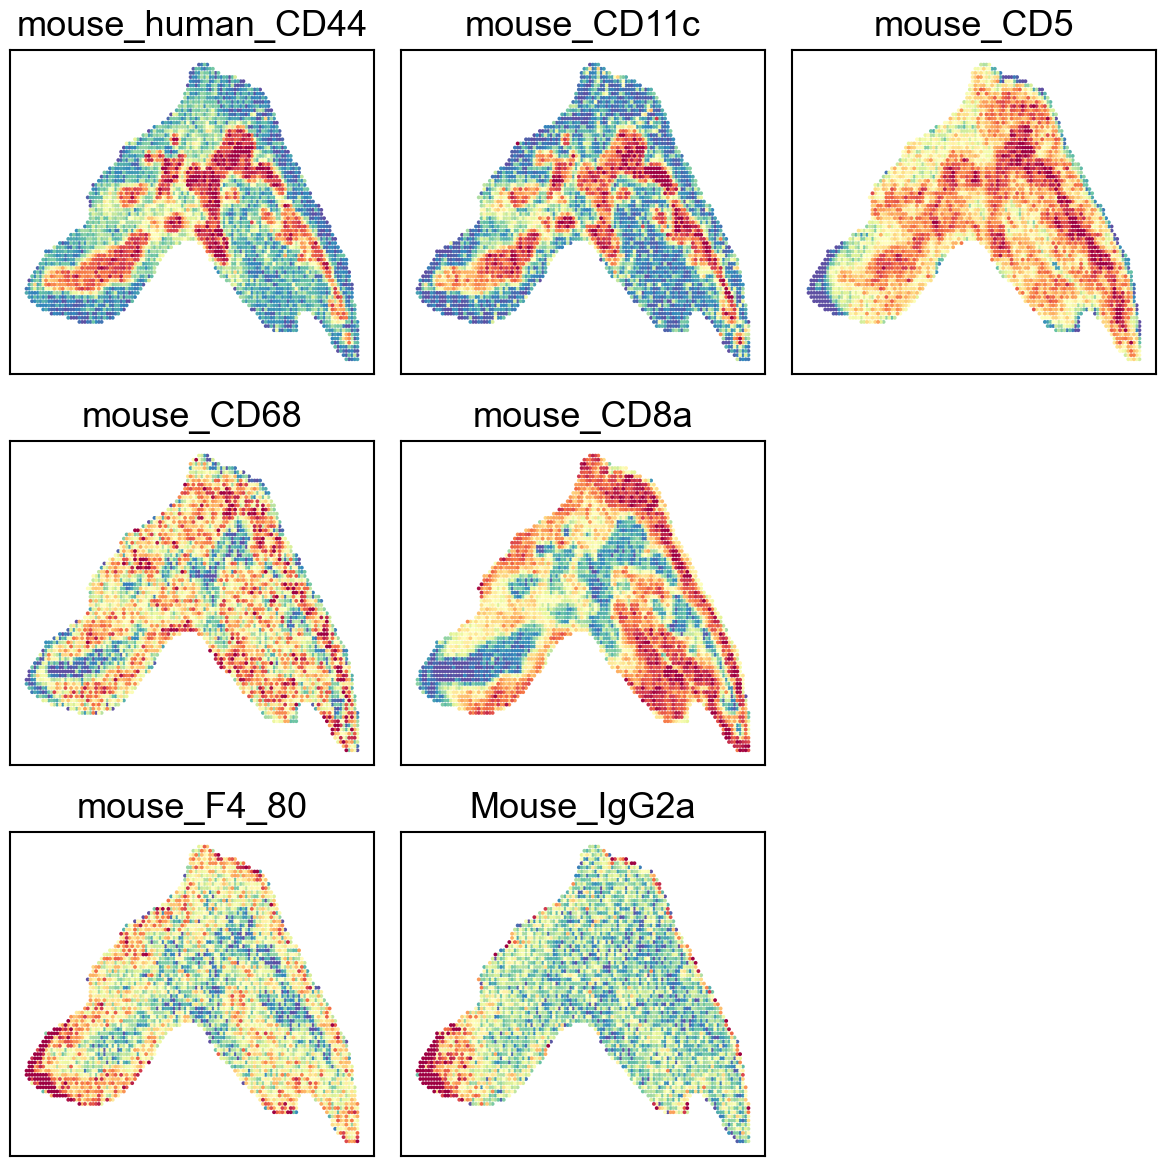

In [15]:
num_genes = len(gene_list)  # Number of genes

plt.rcParams['font.size'] = 18
plt.rcParams['font.sans-serif'] = 'Arial'


# Define the number of columns for each row
num_cols_per_row = [3, 2, 2]  # First row has 3 columns, second and third rows have 2 columns each
num_rows = len(num_cols_per_row)  # Total number of rows

# Calculate the total number of columns needed
max_num_cols = max(num_cols_per_row)

# Create a subplot layout with the maximum number of columns
fig, axs = plt.subplots(num_rows, max_num_cols, figsize=(max_num_cols * 4, num_rows * 4), squeeze=False)

# Iterate over the gene list and create a subplot for each gene
gene_index = 0
for row, num_cols in enumerate(num_cols_per_row):
    for col in range(num_cols):
        if gene_index < num_genes:
            gene = gene_list[gene_index]
            expression = adata_modality_2[:, gene].X.toarray().flatten()
            adata_modality_2[:, gene].X = replace_extreme_values(expression, n=0.02)
            
            sc.pl.embedding(adata_modality_2, basis='spatial', color=gene, ax=axs[row, col], s=30, colorbar_loc=None, show=False, cmap='Spectral_r')

            # Remove the spines of the subplot
            for spine in axs[row, col].spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)

            # Remove x and y axis labels
            axs[row, col].set_xlabel('')
            axs[row, col].set_ylabel('')

            # Set title with increased vertical spacing
            axs[row, col].set_title(gene, pad=10, fontsize=26)  # Adjust pad value to increase spacing

            if replicate == 1 or replicate == 2:
                axs[row, col].invert_yaxis()
            elif replicate == 3:
                axs[row, col].invert_xaxis()
            gene_index += 1

# Hide unused subplots
for row, num_cols in enumerate(num_cols_per_row):
    for col in range(num_cols, max_num_cols):
        axs[row, col].axis('off')  # Turn off the axis
        for spine in axs[row, col].spines.values():
            spine.set_visible(False)  # Hide the spines

plt.tight_layout()

plt.savefig(f"./replicate{replicate}/marker_proteins.png", dpi=800)
plt.savefig(f"./replicate{replicate}/marker_proteins.eps")